### **Image Sampling and Quantization** 🖼️

▓▓▓▓▓▓▓▓    Original 

░░░░░░░░    Sampled

▒▒▒▒▒▒▒▒    Quantized



#### *Importing the libraries* 🛠️

In [8]:
import cv2
import numpy as np 
import matplotlib.pyplot as plt 

#### *Defining the functions* ⚙️


#####  -- *Sample Image function* --

In [9]:
def sample_image(image: np.ndarray, factor: int) -> np.ndarray:
    """
    Downsamples the image by the given factor.

    Args:
        image (np.ndarray): Original grayscale image.
        factor (int): Factor by which to downsample.

    Returns:
        np.ndarray: Downsampled image.
    """
    height, width = image.shape[:2]
    sampled_image = cv2.resize(
        image,
        (width // factor, height // factor),
        interpolation=cv2.INTER_NEAREST
    )
    return sampled_image

#####  -- *Quantized Image function* --

In [10]:
import numpy as np

def quantize_image(image, levels):
    """
    Reduces the number of grayscale levels in the image.

    Args:
        image (numpy array): Original image.
        levels (int): Number of grayscale levels.

    Returns:
        numpy array: Quantized image.
    """
    quantized_image = np.floor(image / (256 // levels)) * (256 // levels)
    quantized_image = quantized_image.astype(np.uint8)
    return quantized_image


#####  -- *Plot Image function* --

In [11]:
import matplotlib.pyplot as plt

def plot_images(original, sampled, quantized):
    """
    Plots the original, sampled, and quantized images side by side.

    Args:
        original (numpy array): Original image.
        sampled (numpy array): Sampled image.
        quantized (numpy array): Quantized image.
    """
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(sampled, cmap='gray')
    plt.title('Sampled Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(quantized, cmap='gray')
    plt.title('Quantized Image')
    plt.axis('off')

    plt.show()


#### *importing the image and setting the parameters* 📥


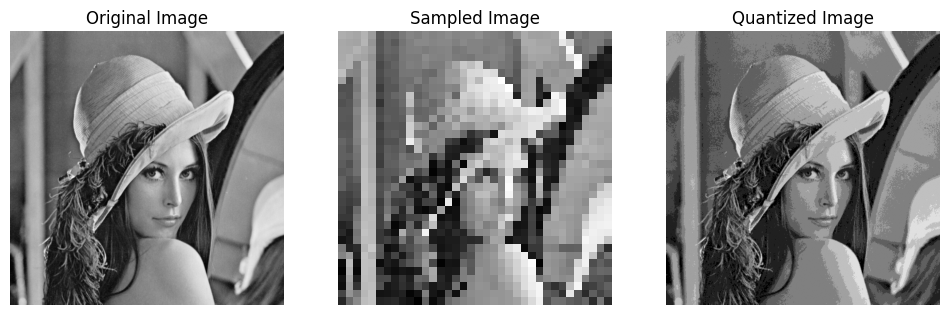

In [12]:

image_path = 'GirlImage.gif'
sampling_factor = 14
quantization_levels = 9

# Load image in grayscale
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    # Sample and quantize
    sampled_image = sample_image(original_image, sampling_factor)
    quantized_image = quantize_image(original_image, quantization_levels)

    # Plot results
    plot_images(original_image, sampled_image, quantized_image)


from PIL import Image
img1 = Image.open('GirlImage.gif')
img2 = Image.open('GirlImage.gif')   # Replace with another image if needed

resize_size = (400, 400)

img1 = img1.resize(resize_size, Image.Resampling.LANCZOS)
img2 = img2.resize(resize_size, Image.Resampling.LANCZOS)

im1arr = np.asarray(img1)
im2arr = np.asarray(img2)

addition = im1arr + im2arr
resultImage = Image.fromarray(addition.astype(np.uint8))
resultImage.show()

img3 = Image.open('GirlImage.gif')
img4 = Image.open('GirlImage.gif')   # Replace with another image if needed

img3 = img3.resize(resize_size, Image.Resampling.LANCZOS)
img4 = img4.resize(resize_size, Image.Resampling.LANCZOS)

im3arr = np.asarray(img3)
im4arr = np.asarray(img4)

union = im4arr | im3arr
resultImage2 = Image.fromarray(union.astype(np.uint8))
resultImage2.show()

### ***Task 1***: Change the sampling and quantization parameters and observe the effects

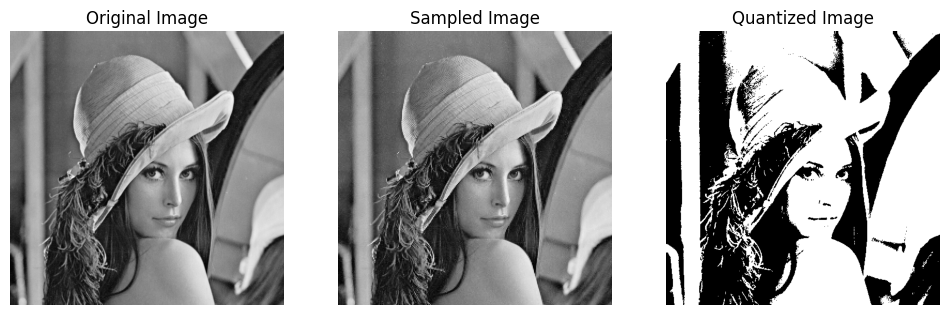

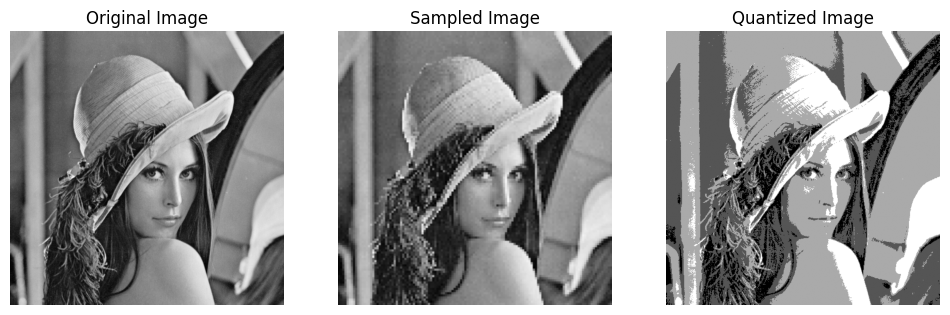

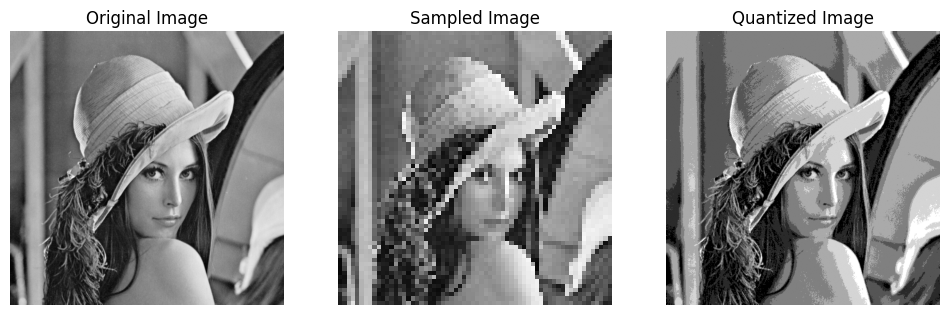

In [18]:
image_path = 'GirlImage.gif'
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if original_image is None:
    print(f"Error: Unable to load image at {image_path}")
else:
    # 3 example combinations
    examples = [
        (2, 2),    # light sampling, very low gray levels
        (4, 4),    # medium sampling and quantization
        (8, 8)     # heavy sampling, moderate gray levels
    ]

    for sf, ql in examples:
        sampled = sample_image(original_image, sf)
        quantized = quantize_image(original_image, ql)
        plot_images(original_image, sampled, quantized)


### ***Task 2*** 
### 1. Subtract two images and display the result.
### 2. Add one image with a constant value of 175 and display it.
### 3. Apply the set difference operation on two Gray-Scale images.
### 4. Apply the symmetric difference operation on two Gray-Scale images.
### 5. Apply Intersection operations on two Gray-Scale images 


##

Running Task 2 ...



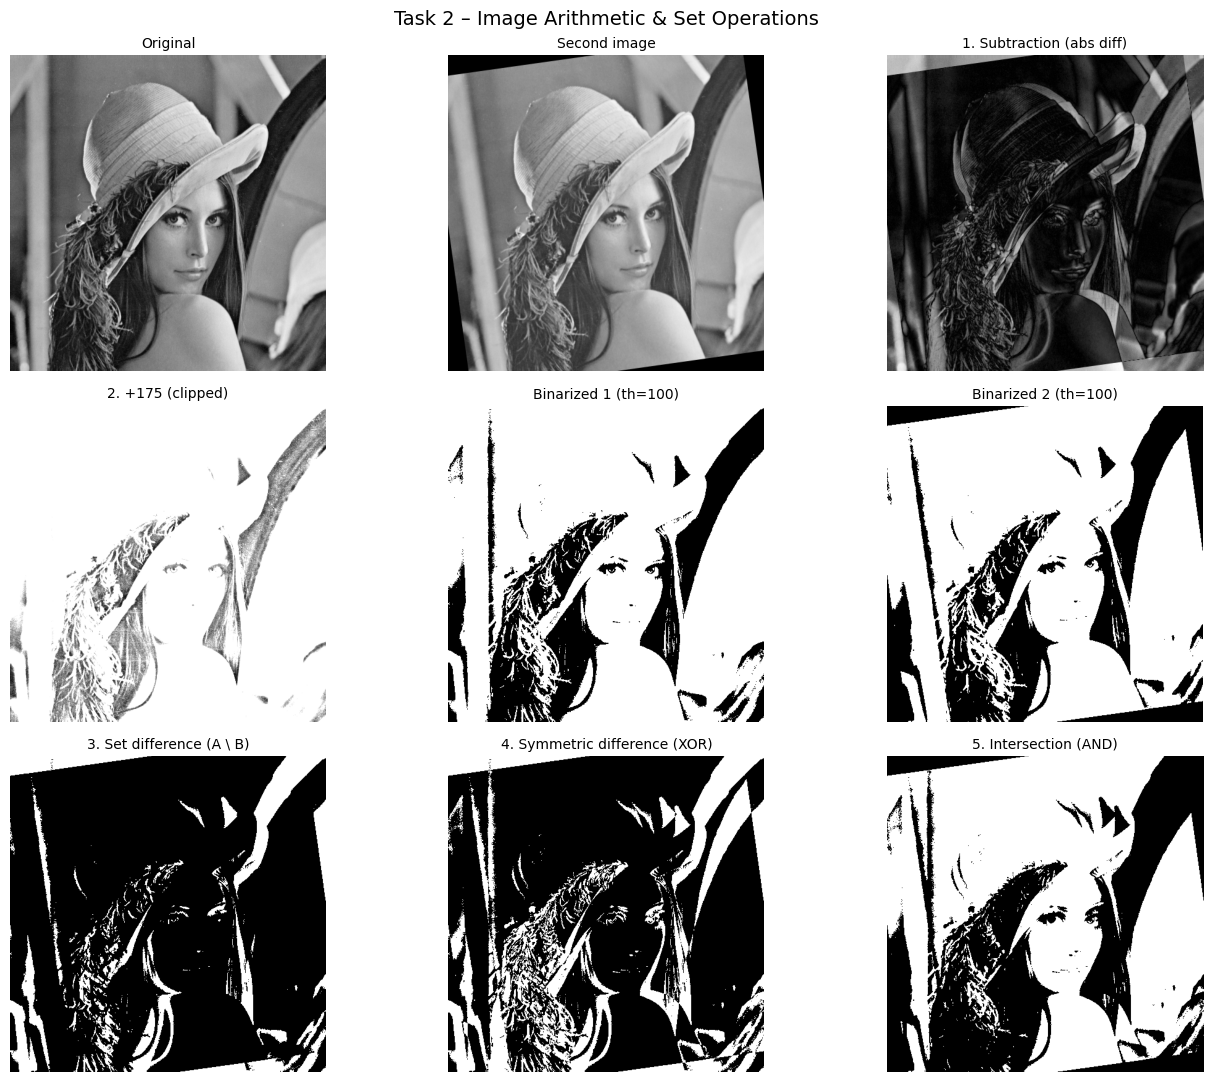

In [ ]:
def match_size(img1, img2):
    if img1.shape != img2.shape:
        h, w = img1.shape[:2]
        img2 = cv2.resize(img2, (w, h), interpolation=cv2.INTER_NEAREST)
    return img1, img2


# 1. Subtract two images (absolute difference – most common interpretation)
def subtract_images(img1, img2):
    img1, img2 = match_size(img1, img2)
    # Absolute difference prevents negative values
    result = cv2.absdiff(img1, img2)
    return result


# 2. Add constant value (175) with proper clipping
def add_constant(img, value=175):
    # Use larger type to avoid wrap-around, then clip & convert back
    result = np.clip(img.astype(np.int16) + value, 0, 255).astype(np.uint8)
    return result


# 3. Set difference    A \ B   = pixels in A but not in B
# 4. Symmetric difference   A Δ B   = (A \ B) ∪ (B \ A)
# 5. Intersection      A ∩ B
#
# → We'll binarize first (common classroom approach for set operations on images)
def binarize(img, thresh=100):
    # You can experiment with different thresholds: 90, 100, 120, 128, ...
    _, binary = cv2.threshold(img, thresh, 255, cv2.THRESH_BINARY)
    return binary


def set_difference(img1, img2, thresh=100):
    img1, img2 = match_size(img1, img2)
    b1 = binarize(img1, thresh)
    b2 = binarize(img2, thresh)
    # A and (not B)
    return cv2.bitwise_and(b1, cv2.bitwise_not(b2))


def symmetric_difference(img1, img2, thresh=100):
    img1, img2 = match_size(img1, img2)
    b1 = binarize(img1, thresh)
    b2 = binarize(img2, thresh)
    # XOR = symmetric difference on binary images
    return cv2.bitwise_xor(b1, b2)


def intersection(img1, img2, thresh=100):
    img1, img2 = match_size(img1, img2)
    b1 = binarize(img1, thresh)
    b2 = binarize(img2, thresh)
    # AND = intersection on binary images
    return cv2.bitwise_and(b1, b2)

def show_task2_results(original, second_img=None):
    if second_img is None:
        # Create a slightly different version if no second image is provided
        h, w = original.shape
        M = cv2.getRotationMatrix2D((w/2, h/2), 8, 1.0)   # small rotation
        second_img = cv2.warpAffine(original, M, (w, h))

    # Compute all results
    sub    = subtract_images(original, second_img)
    added  = add_constant(original, 175)
    diff   = set_difference(original, second_img, thresh=100)
    symdiff = symmetric_difference(original, second_img, thresh=100)
    inter  = intersection(original, second_img, thresh=100)

    # Also prepare binarized versions for reference
    bin1 = binarize(original, 100)
    bin2 = binarize(second_img, 100)

    names = [
        "Original",
        "Second image",
        "1. Subtraction (abs diff)",
        "2. +175 (clipped)",
        "Binarized 1 (th=100)",
        "Binarized 2 (th=100)",
        "3. Set difference (A \\ B)",
        "4. Symmetric difference (XOR)",
        "5. Intersection (AND)"
    ]

    images = [
        original, second_img, sub, added,
        bin1, bin2, diff, symdiff, inter
    ]

    fig, axes = plt.subplots(3, 3, figsize=(14, 11))
    axes = axes.ravel()

    for ax, img, title in zip(axes, images, names):
        ax.imshow(img, cmap='gray')
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    plt.suptitle("Task 2 – Image Arithmetic & Set Operations", fontsize=14, y=0.98)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    image_path = 'GirlImage.gif'

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Cannot load {image_path}")
    else:
        print("Running Task 2 ...\n")
        show_task2_results(img)           # uses rotated version as second image
        # If you have two different images, do:
        # img2 = cv2.imread("other.gif", cv2.IMREAD_GRAYSCALE)
        # show_task2_results(img, img2)